In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.config.set_visible_devices(tf.config.list_physical_devices('GPU')[1], 'GPU') ###

import hmc_1hl as hmc

In [4]:
d = 150
alpha = 5
gamma = 0.5
Delta = 0.1
vlaw = 'ones'
k = int(gamma * d)

sig = lambda x: tf.nn.relu(x)

params = {
    'step_size': 0.01,
    'num_leapfrog_steps': 10,
    'num_adaptation_steps': 500,
}

ntest = 50000
Xtest = tf.random.normal((d, ntest), dtype=tf.float32)

In [5]:
W0, v, X, Y = hmc.data_generate(d, alpha, gamma, sig, Delta, vlaw)
W1s = hmc.hmc(params, W0, v, X, Y, Delta, sig, info=False)
W2s = hmc.hmc(params, W0, v, X, Y, Delta, sig, info=False)

In [6]:
e12 = np.array([hmc.test_error(W1s[i], W2s[i], v, sig, Xtest) for i in range(0, W1s.shape[0])])
e01 = np.array([hmc.test_error(W1s[i], W0, v, sig, Xtest) for i in range(0, W1s.shape[0])])
e02 = np.array([hmc.test_error(W2s[i], W0, v, sig, Xtest) for i in range(0, W1s.shape[0])])

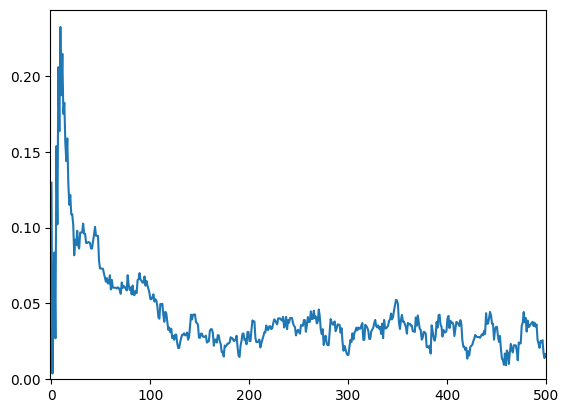

In [7]:
plt.plot(np.abs(e12/e01-1))
plt.xlim(-1,500)
plt.ylim(0,)
plt.show()


In [28]:
# np.savetxt('dev_unfo.csv', e12/e01-1, delimiter=',')

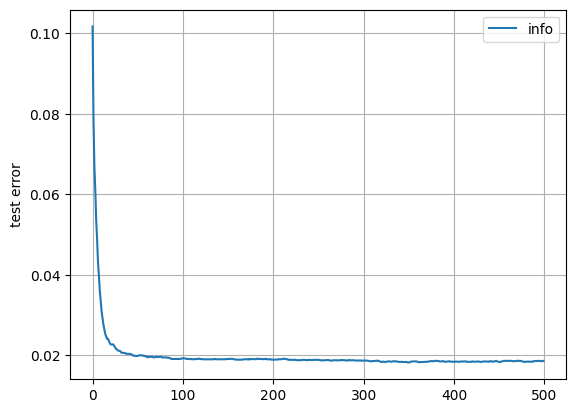

In [8]:
test_info = [hmc.test_error(W, W0, v, sig, Xtest) for W in W1s]
plt.plot(test_info, label='info')
plt.ylabel('test error')
plt.legend()
plt.grid()
plt.show()